In [1]:
import torch
from torch.optim import Optimizer
from torch.utils.data import DataLoader
import transformers
from transformers import (
    BertTokenizerFast, 
    BertForMaskedLM,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import math
import copy

#smallGPT
from transformers import GPT2Config, GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset

/home/janek/ds/2/oda/OptimizationDataAnalysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Alg1Optim(Optimizer):
    def __init__(self,
                params, 
                lr=1e-3,
                momentum=0.9,
                clipper=1.0):

        defaults = dict(lr=lr, momentum=momentum, clipper=clipper)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self,closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            clipper = group['clipper']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                state = self.state[p]

                #initialization

                if len(state) == 0:
                    state['m'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                m_t = state['m']

                # 1. Gradient clipping

                grad_norm = torch.norm(grad, p=2)
                clip_coef = clipper / (grad_norm + 1e-8)

                # min(tau, |grad|) can be realized with clamp()

                clip_coef = torch.clamp(clip_coef, max=1.0)
                g_clip = grad * clip_coef

                # 2. Momentum update
                m_t.mul_(momentum).add_(g_clip, alpha=1.0 - momentum)


                # 3. Normalized weight update
                m_norm = torch.norm(m_t, p=2)
                direction = m_t / (m_norm + 1e-8)
                p.add_(direction, alpha=-lr)
            
        return loss
    
class Alg2Optim(Optimizer):
    def __init__(self,
                params, 
                lr=1e-3,
                momentum=0.9,
                clipper=1.0):

        defaults = dict(lr=lr, momentum=momentum, clipper=clipper)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self,closure=None):
        loss = None
        
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            clipper = group['clipper']

            for p in group['params']:
                state = self.state[p]

                #initialization

                if len(state) == 0:
                    state['m'] = torch.zeros_like(p, memory_format=torch.preserve_format)
                    state['prev_p'] = p.data.clone()

                m_t = state['m']
                prev_p = state['prev_p']

                # Compute x_t = w_t + β(w_t - w_{t-1})/(1-β)
                x_t = p.data + (momentum / (1.0 - momentum)) * (p.data - prev_p)

                # Store current w_t for later restoration
                p_curr = p.data.clone()

                # Shift parameters to x_t and evaluate gradient there
                p.data = x_t
                if closure is not None:
                    with torch.enable_grad():
                        loss = closure()

                grad = p.grad
                
                # Restore parameters to w_t
                p.data = p_curr

                if grad is None:
                    continue

                # 1. Gradient clipping

                grad_norm = torch.norm(grad, p=2)
                clip_coef = clipper / (grad_norm + 1e-8)

                # min(tau, |grad|) can be realized with clamp()

                clip_coef = torch.clamp(clip_coef, max=1.0)
                g_clip = grad * clip_coef

                # 2. Momentum update
                m_t.mul_(momentum).add_(g_clip, alpha=1.0 - momentum)


                # 3. Normalized weight update
                m_norm = torch.norm(m_t, p=2)
                direction = m_t / (m_norm + 1e-8)
                p.add_(direction, alpha=-lr)

                # Store current p for next iteration
                state['prev_p'] = p_curr
            
        return loss

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") 
else:
    device = torch.device("cpu")  

print(f"Using device: {device}")

Using device: cpu


In [4]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token 

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=128,
    n_embd=256,
    n_layer=4,
    n_head=4
)

model = GPT2LMHeadModel(config)
model.to(device)

batch_size = 16
max_length = 128 
epochs = 1

#datasets = load_dataset("wikitext", "wikitext-2-raw-v1")

datasets = load_dataset("wikitext", "wikitext-103-raw-v1") #more data - less overfitting?

#prepare smaller dataset
#datasets["train"] = datasets["train"].select(range(10000))
#datasets["validation"] = datasets["validation"].select(range(2000))
#datasets["test"] = datasets["test"].select(range(2000))

def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        truncation=True, 
        padding="max_length",
        max_length=max_length
    )

tokenized_datasets = datasets.map(
    tokenize_function, 
    batched=True, 
    num_proc=4, 
    remove_columns=["text"]
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, 
    mlm=False 
)

HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.

In [ ]:
#def tokenize_function(examples):
#    return tokenizer(
#        examples["text"], 
#        return_special_tokens_mask=True,
#        truncation=True, 
#        max_length=max_length
#    )

#filtered_datasets = datasets.filter(lambda x: len(x["text"]) > 10)

#tokenized_datasets = filtered_datasets.map(
#    tokenize_function, 
#    batched=True, 
#    num_proc=4, 
#    remove_columns=["text"]
#)

In [5]:
#data_collator = DataCollatorForLanguageModeling(
#    tokenizer=tokenizer, 
#    mlm=True, 
#    mlm_probability=0.15 
#)

train_dataloader = DataLoader(
    tokenized_datasets["train"], 
    shuffle=True, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], 
    shuffle=False, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

test_dataloader = DataLoader(
    tokenized_datasets["test"], 
    shuffle=False, 
    batch_size=batch_size, 
    collate_fn=data_collator
)

print(f"Training set batches: {len(train_dataloader)}")
print(f"Validation set batches: {len(val_dataloader)}")
print(f"Test set batches: {len(test_dataloader)}")

NameError: name 'tokenized_datasets' is not defined

In [ ]:
def evaluate_on_test_set(model_to_test, dataloader, device, model_name):
    model_to_test.eval()
    total_test_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_to_test(**batch)
            loss = outputs.loss
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(dataloader)
    
    test_perplexity = math.exp(avg_test_loss)
    
    print(f"Scores for: {model_name}")
    print(f"Average Loss: {avg_test_loss:.4f}")
    print(f"Perplexity:  {test_perplexity:.4f}\n")

In [ ]:
import math
import torch
import numpy as np
from tqdm.auto import tqdm

def training_loop(model, optimizer, train_dataloader, val_dataloader, epochs, device, burnin_steps=0, warmup_steps=0, steps_before_decay=3125, eval_steps=200, s=1e-4):
    assert burnin_steps == 0 or warmup_steps == 0, "Burn-in and warmup cannot be chosen simultaneously."
    
    num_training_steps = epochs * len(train_dataloader)
    progress_bar = tqdm(range(num_training_steps), desc="Training")
    
    train_losses = []
    train_grad_norms = []
    train_accuracies = []
    
    val_losses = [] 
    val_accuracies = [] 
    val_steps = []
    
    global_step = 0 
    initial_lrs = [group['lr'] for group in optimizer.param_groups]
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        model.train()
        
        for step, batch in enumerate(train_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            if global_step < burnin_steps: # burn-in 
                for group in optimizer.param_groups:
                    group['lr'] = 0.0
            elif global_step < warmup_steps: # warmup 
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]*(global_step/warmup_steps)
            elif global_step < steps_before_decay: 
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]
            else: # decay 
                for i, group in enumerate(optimizer.param_groups):
                    group['lr'] = initial_lrs[i]*(1 - (global_step - steps_before_decay)/(num_training_steps - steps_before_decay))
        

            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            
            # add noise to every parameter gradient
            for p in model.parameters():
                if p.grad is not None:
                    p.grad.add_(torch.empty_like(p.grad).cauchy_(median=0, sigma=s))
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1e6).cpu().item() 
            
            optimizer.step()
            
            loss_val = loss.item()

            if math.isnan(loss_val) or math.isinf(loss_val):
                if len(train_losses) > 0 and not math.isnan(train_losses[-1]):
                    print(f"\n[Loss exploded to inf/nan] at step {global_step}!")
                train_losses.append(math.nan)
            else:
                train_losses.append(loss_val)
            
            if math.isnan(grad_norm) or math.isinf(grad_norm):
                train_grad_norms.append(math.nan)
            else:
                train_grad_norms.append(grad_norm)
            
            preds = torch.argmax(outputs.logits, dim=-1)
            labels = batch['labels']
            shifted_preds = preds[:, :-1]
            shifted_labels = labels[:, 1:]
            mask = shifted_labels != -100
            if mask.sum() > 0:
                acc = (shifted_preds[mask] == shifted_labels[mask]).sum().float() / mask.sum().float()
                train_accuracies.append(acc.item())

            if global_step % 200 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                loss_print = f"{loss_val:.4f}" if not math.isnan(loss_val) else "NaN"
                norm_print = f"{grad_norm:.3f}" if not math.isnan(grad_norm) else "NaN"
                print(f"Step {global_step} | Loss: {loss_print} | Norm: {norm_print} | LR: {current_lr:.6f}")
    
            if global_step % eval_steps == 0 and global_step > 0:
                model.eval()
                total_val_accuracy = 0 
                step_val_losses = []
                
                with torch.no_grad():
                    for v_step, v_batch in enumerate(val_dataloader):
                        if v_step >= 100: 
                            break 
                        
                        v_batch = {k: v.to(device) for k, v in v_batch.items()}
                        v_outputs = model(**v_batch)
                        
                        v_loss = v_outputs.loss.item()
                        if not math.isnan(v_loss) and not math.isinf(v_loss):
                            step_val_losses.append(v_loss)
                            
                        v_preds = torch.argmax(v_outputs.logits, dim=-1)
                        v_labels = v_batch['labels']
                        v_shifted_preds = v_preds[:, :-1]
                        v_shifted_labels = v_labels[:, 1:]
                        v_mask = v_shifted_labels != -100
                        if v_mask.sum() > 0:
                            v_acc = (v_shifted_preds[v_mask] == v_shifted_labels[v_mask]).sum().float() / v_mask.sum().float()
                            total_val_accuracy += v_acc.item()
                
                val_batches_checked = min(100, len(val_dataloader))
                avg_val_acc = total_val_accuracy / val_batches_checked
                avg_val_loss = np.nanmean(step_val_losses) if step_val_losses else float('nan')
                
                val_steps.append(global_step)
                val_losses.append(avg_val_loss)
                val_accuracies.append(avg_val_acc)
                
                print(f"--> [EVAL Step {global_step}] Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc * 100:.2f}%")

                model.train() 

            if global_step >= 5000:
                print("5000 steps - end of training")
                return train_losses, train_grad_norms, train_accuracies, val_losses, val_accuracies, val_steps

            progress_bar.update(1)
            global_step += 1
            
    return train_losses, train_grad_norms, train_accuracies, val_losses, val_accuracies, val_steps

In [ ]:
import torch.optim as optim
from transformers import GPT2LMHeadModel
import numpy as np


TEST_CONFIGS = [
    ("SGD_Baseline", optim.SGD, 0, 0),
    ("SGD_Warmup", optim.SGD, 0, 400),
    ("Adam_Baseline", optim.Adam, 0, 0),
    ("Adam_Warmup", optim.Adam, 0, 400),
    ("Alg1_Burnin", Alg1Optim, 400, 0),
    ("Alg1_Warmup", Alg1Optim, 0, 400),
    ("Alg2_Burnin", Alg2Optim, 400, 0),
    ("Alg2_Warmup", Alg2Optim, 0, 400)
]

lr = 3e-4

for name, opt_class, b_steps, w_steps in TEST_CONFIGS:
    print(f"\n--- Starting: {name} ---")
    
    model_custom = GPT2LMHeadModel(config).to(device)
    
    if opt_class == Alg1Optim:
        optimizer = Alg1Optim(model_custom.parameters(), lr=lr, momentum=0.99, clipper=1.0)
    else:
        optimizer = opt_class(model_custom.parameters(), lr=lr)
        
    train_loss, train_grad, train_acc, val_loss, val_acc, val_steps = training_loop(
        model_custom, optimizer, train_dataloader, val_dataloader, epochs, device, 
        burnin_steps=b_steps, warmup_steps=w_steps
    )

    np.savetxt(f"train_loss_{name}.txt", train_loss)
    np.savetxt(f"train_grad_{name}.txt", train_grad)
    np.savetxt(f"train_acc_{name}.txt", train_acc)
    np.savetxt(f"val_loss_{name}.txt", val_loss)
    np.savetxt(f"val_acc_{name}.txt", val_acc)
    np.savetxt(f"val_steps_{name}.txt", val_steps)

In [13]:
#TEST_VALUES = [("burnin", 0), ("burnin", 700), ("burnin", 1300), ("warmup", 3125)]
#TEST_VALUES = [("burnin", 0), ("burnin", 400), ("warmup", 400)]

#for name, value in TEST_VALUES:
#    print(f"{name} steps: {value}")
#    model_custom = GPT2LMHeadModel(config).to(device)
#    
#    optimizer_custom = optimizer = Alg1Optim(
#        model_custom.parameters(), 
#        lr=1e-3,
#        momentum=0.99,
#        clipper=1
#    )
#    
#    train_loss_custom, train_grad_custom, train_accuracies_custom, val_loss_custom, val_accuracies_custom = training_loop(
#        model_custom, optimizer_custom, train_dataloader, val_dataloader, epochs, device, burnin_steps=(value if name == "burnin" else 0), warmup_steps=(value if name == "warmup" else 0))
#
#    np.savetxt(f"train_loss_{name}_{value}.txt", train_loss_custom)
#    np.savetxt(f"train_grad_{name}_{value}.txt", train_grad_custom)
#    np.savetxt(f"train_acc_{name}_{value}.txt", train_accuracies_custom)
#    np.savetxt(f"val_loss_{name}_{value}.txt", val_loss_custom)
#    np.savetxt(f"val_acc_{name}_{value}.txt", val_accuracies_custom)

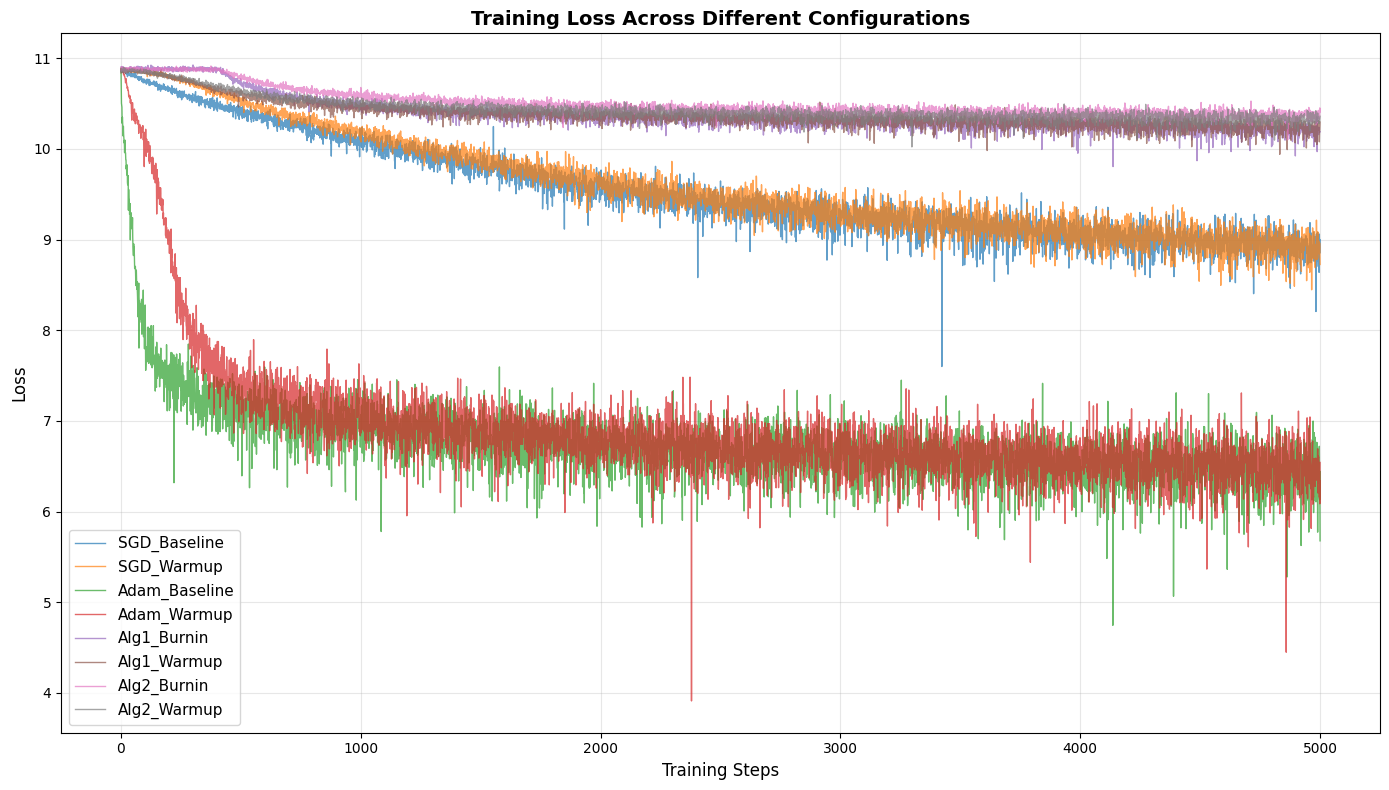

In [5]:
plt.figure(figsize=(14, 8))

for name, _, _, _ in TEST_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/train_loss_{name}.txt")
        plt.plot(train_loss_data, label=f"{name}", linewidth=1, alpha=0.7)
    except FileNotFoundError:
        print(f"File not found: train_loss_{name}.txt")

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss Across Different Configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

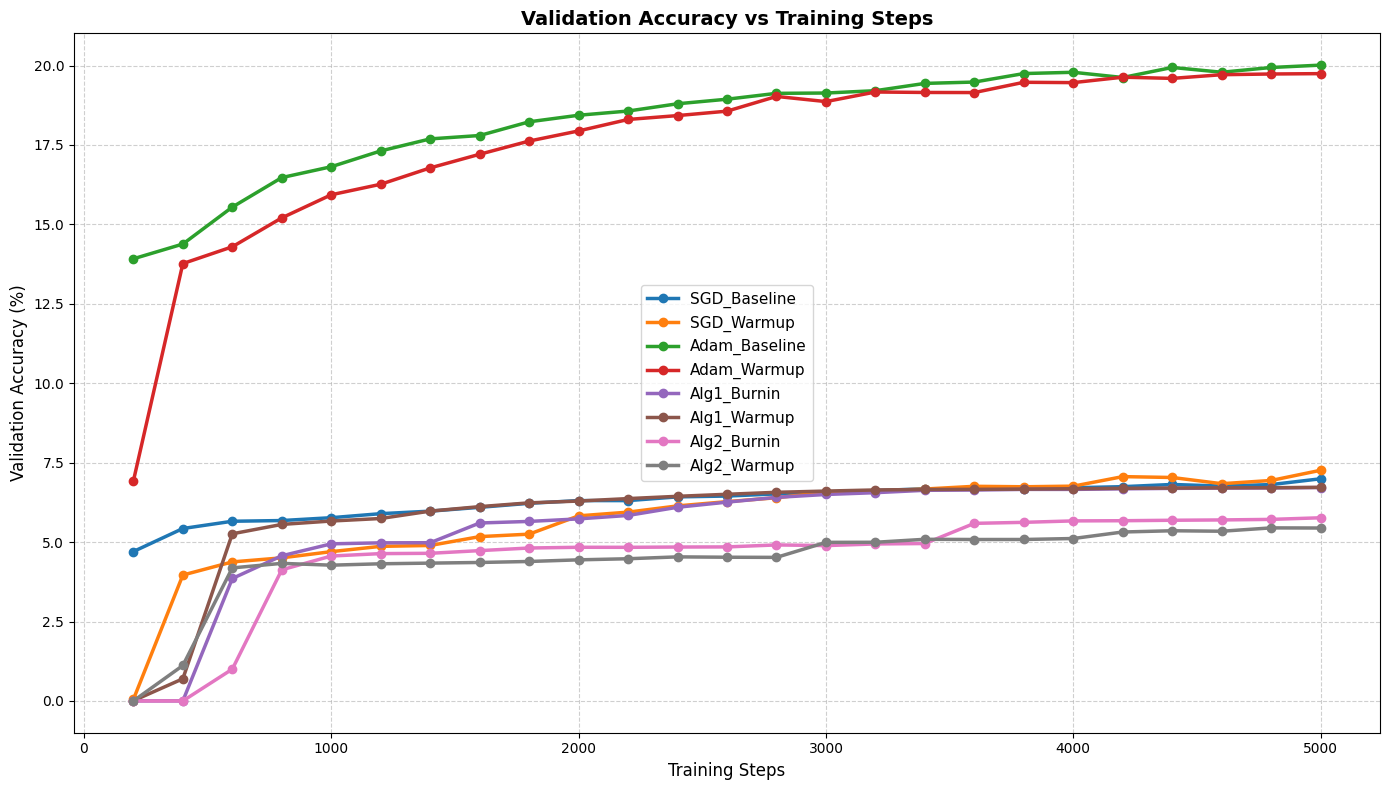

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))

for name, _, _, _ in TEST_CONFIGS:
    try:
        val_acc_data = np.loadtxt(f"smallgpt-tails-results/val_acc_{name}.txt")
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/train_loss_{name}.txt")
        
        epochs_count = len(val_acc_data)
        total_steps = len(train_loss_data)
        steps_per_epoch = total_steps // epochs_count
        
        steps_x = np.arange(1, epochs_count + 1) * steps_per_epoch
        
        plt.plot(steps_x, val_acc_data * 100, label=f"{name}", marker='o', linewidth=2.5)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy vs Training Steps", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('val_accuracy_steps.png', dpi=300)
plt.show()

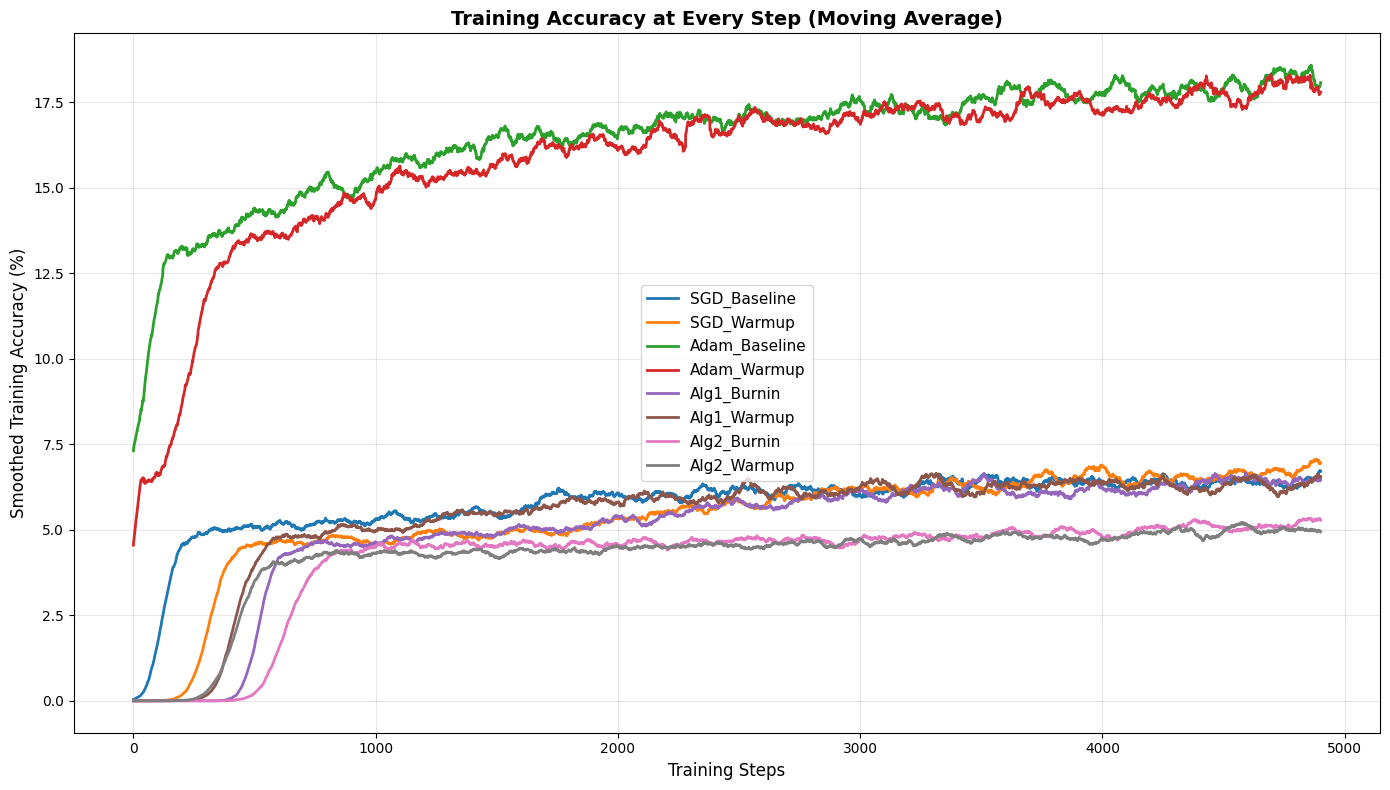

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, _, _, _ in TEST_CONFIGS:
    try:
        train_acc_data = np.loadtxt(f"smallgpt-tails-results/train_acc_{name}.txt")
        
        smoothed_acc = smooth_curve(train_acc_data * 100, window_size=100)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Accuracy (%)", fontsize=12)
plt.title("Training Accuracy at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('train_accuracy_smoothed.png', dpi=300)
plt.show()

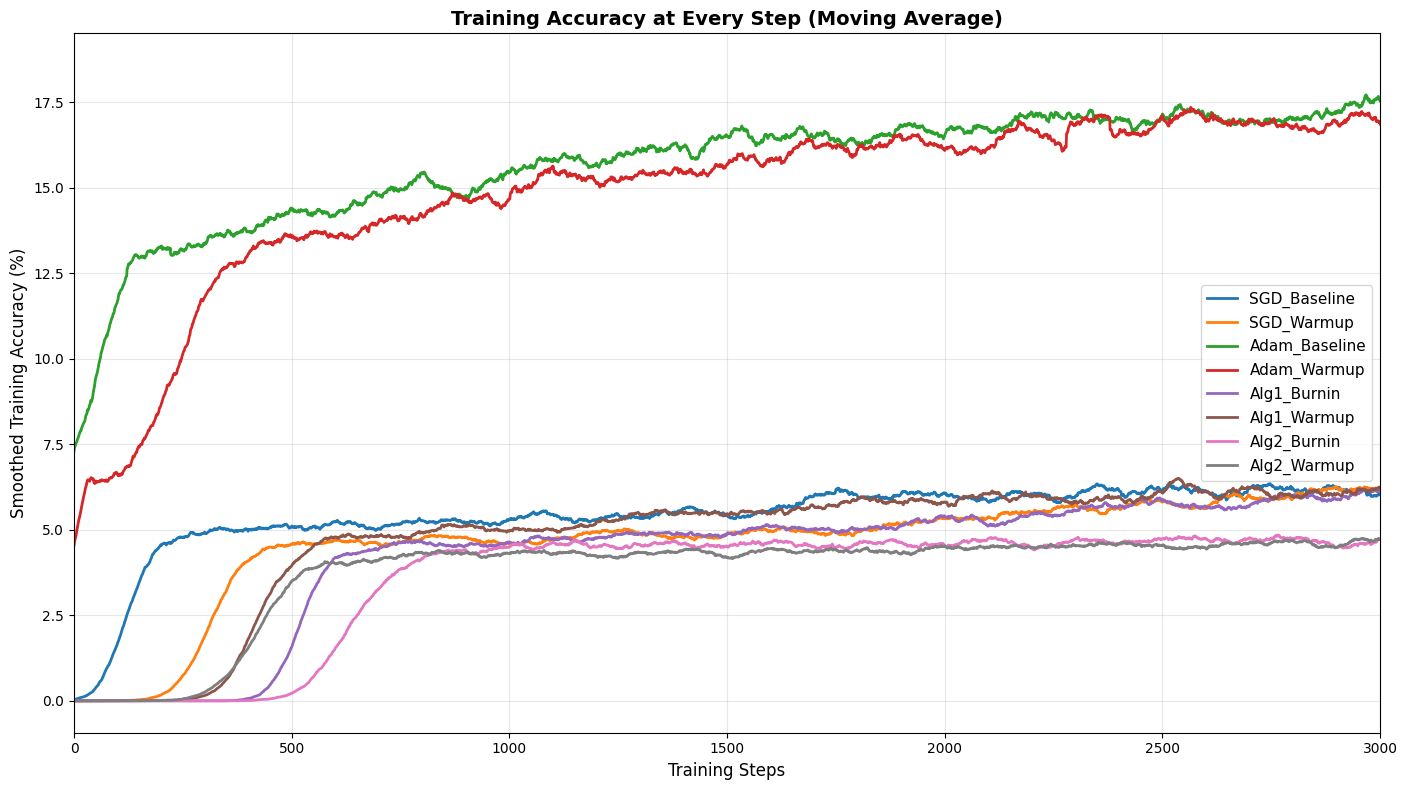

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, _, _, _ in TEST_CONFIGS:
    try:
        train_acc_data = np.loadtxt(f"smallgpt-tails-results/train_acc_{name}.txt")
        
        smoothed_acc = smooth_curve(train_acc_data * 100, window_size=100)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Accuracy (%)", fontsize=12)
plt.title("Training Accuracy at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xlim(0, 3000)
plt.savefig('train_accuracy_smoothed_zoom.png', dpi=300)
plt.show()